Bank Customer Churn Prediction. 

The aim of this project is to analyze the bank customer's demographics and financial information. 

About the Dataset

The dataset is taken from kaggle. 

Data Dictionary 

Column name 

In [128]:
## importing libraries 
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

Loading the Dataset

In [129]:
bank_data = pd.read_csv('Bank_Churn.csv')
bank_data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Data Preprocessing 1

In [130]:
## Checking the shape of the dataset 
bank_data.shape

(10000, 13)

In [131]:
# checking the info of the dataset 
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


Dropping unecessary columns -- CustomerId, Surname. 
For this analysis, they are not needed.  

In [132]:
bank_data.drop(columns=['CustomerId', 'Surname'], axis=1 ,inplace=True)
bank_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Checking for Null/Missing values

In [133]:
bank_data.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Checking the data types of the columns 

In [134]:
bank_data.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Checking for duplicates. 

In [135]:
bank_data.duplicated().sum()

np.int64(0)

Renaming the column 'Exited' to 'Churn'

In [136]:
bank_data.rename(columns={'Exited':'Churn'}, inplace=True)
bank_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Descriptive Statistics

In [137]:
bank_data.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Churn,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


Explarative Data Analysis. 

Pie Chart for customer churn

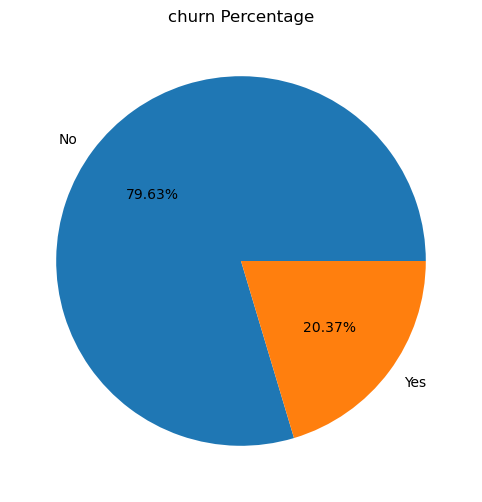

In [138]:
plt.figure(figsize=(12, 6))
plt.pie(bank_data['Churn'].value_counts(), labels=['No', 'Yes'], autopct='%1.2f%%')
plt.title('churn Percentage')
plt.show()

The pie chart clearly visulaizes the customer churn in the bank data. The chart show that majority of the customers in the dataset cotinue to use the bank services with only 20.4% of the customers churning. 

Gender 

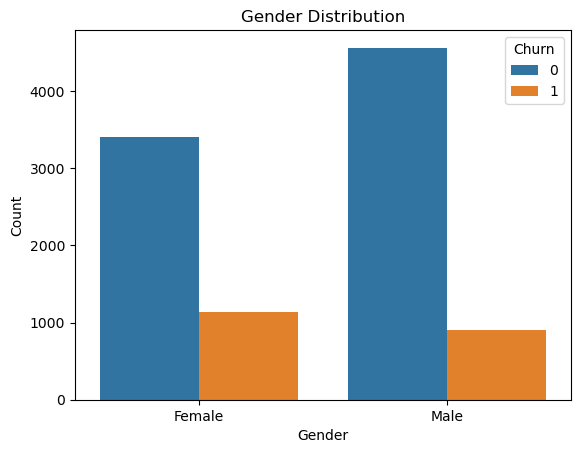

In [139]:
sns.countplot(data=bank_data, x = 'Gender', hue='Churn')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

As shown in the graph, majority of the bank's customers are male . But looking at the graph plot for gender, we see that females have more tendency to churn as compared to males. Because the churn gap between the two gender isn't must, we cannot conclude that the gender is really affected by the churn rate. 

Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

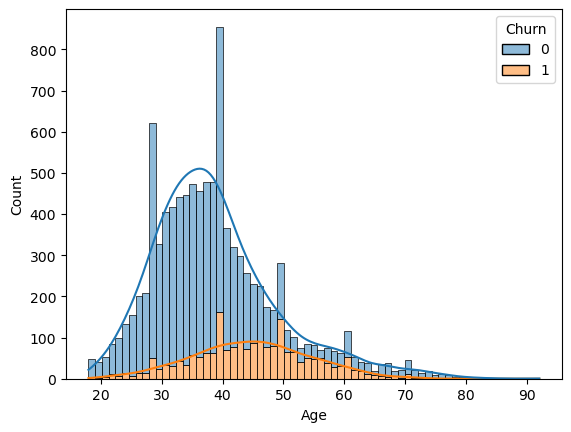

In [140]:
sns.histplot(data=bank_data, x= 'Age', hue='Churn', multiple='stack', kde=True)


The histogram visualizes the age distribution and the churn count of the customers. The majority of the customers are from the age 30-40 years old. The customer churn count is highest for the customer from the ge group 40-50. Customer from age group 20-25 count lowest for the customer churn count. Therefore, age plays a vital role in customer churn where late adults are more likely to churn compared to young adults with minimal churn count.  

credit Score

<Axes: xlabel='Churn', ylabel='CreditScore'>

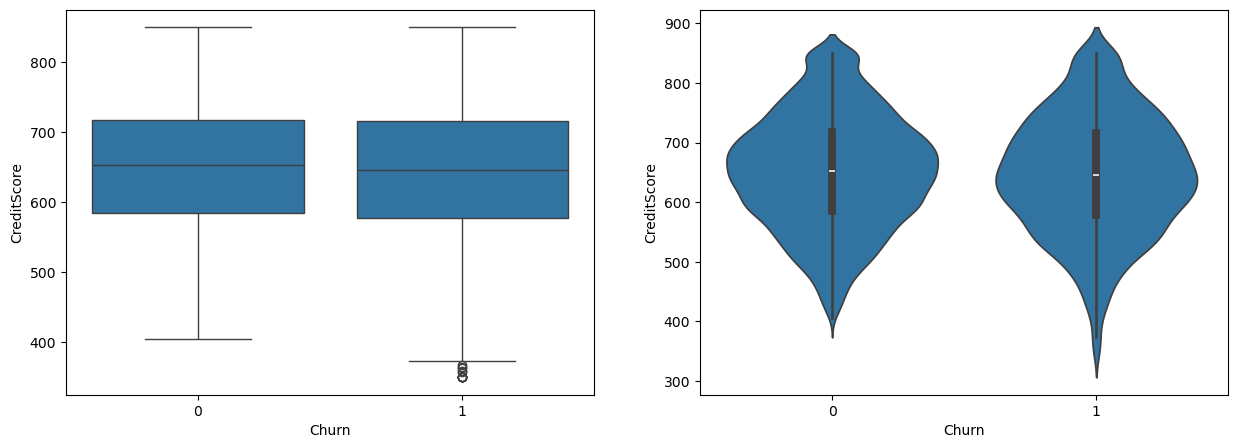

In [145]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=bank_data, x= 'Churn', y= 'CreditScore', ax=ax[0])
sns.violinplot(data=bank_data, x='Churn', y= 'CreditScore', ax=ax[1])


Customer Location 

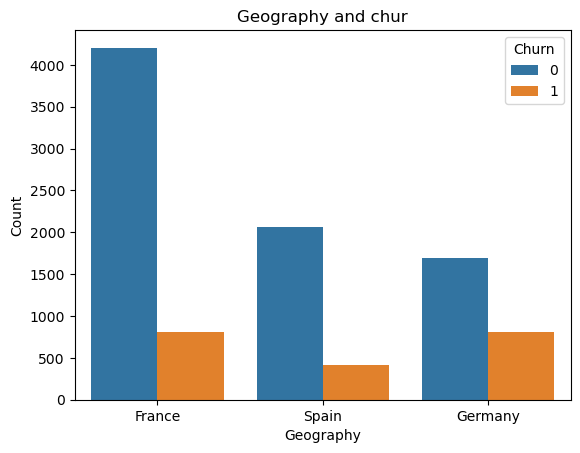

In [ ]:
sns.countplot(data=bank_data, x='Geography', hue='Churn')
plt.title("Geography and chur")
plt.xlabel('Geography')
plt.ylabel('Count')
plt.show()

The graph shows that most of the bank customers are from france but Germany has the highest number of customer churn followed by France and spain. 

Tenure


C:\Users\DELL\AppData\Local\Temp\ipykernel_4192\573282155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=bank_data, x='Tenure', ax=ax[0], palette='Set2')


<Axes: xlabel='Tenure', ylabel='count'>

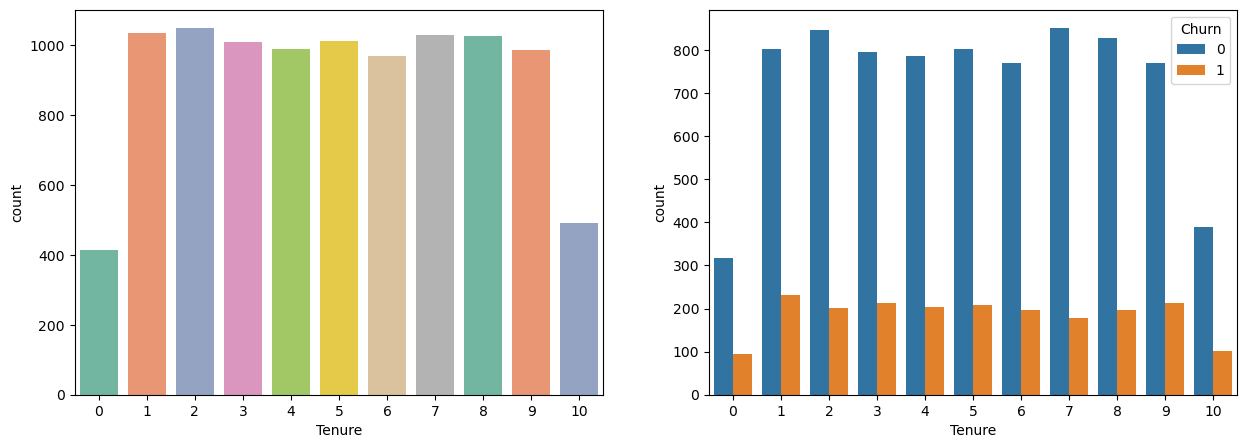

In [ ]:

fig,ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(data=bank_data, x='Tenure', ax=ax[0], palette='Set2')
sns.countplot(data=bank_data, x='Tenure', hue='Churn', ax=ax[1])


The graph shows that most people who have spent around 1-9 years with the bank are the majority. However, the cutomers with 1 year experience with the bank have high churn rate.  

Bank Balance

<Axes: xlabel='Balance', ylabel='Count'>

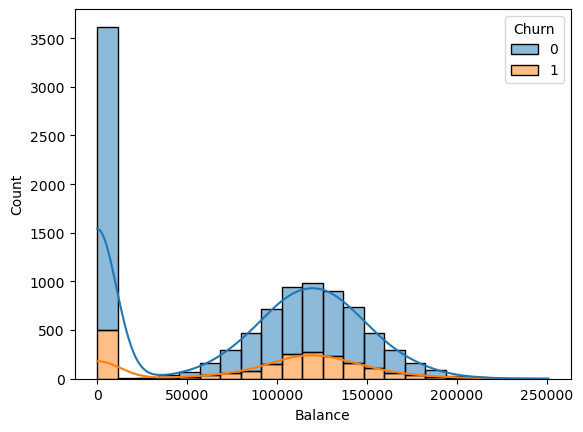

In [ ]:
sns.histplot(data=bank_data, x='Balance', hue='Churn', multiple='stack', kde=True)

The churn rate is quite high in customers with zero balance and the ones with 100000-150000 are likely to leave after those with zero balance. 

Number of products purchased

<Axes: xlabel='NumOfProducts', ylabel='count'>

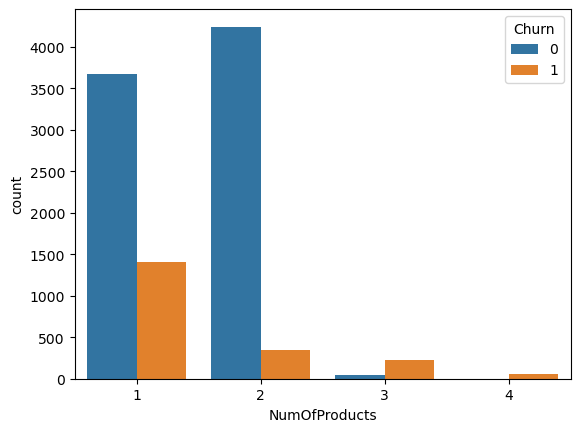

In [ ]:
sns.countplot(data=bank_data, x='NumOfProducts', hue='Churn')

The customers with 1 or 2 products are the majority among the bank's customers and the customers likely to churn faster are those with 3 or 4 products because the non-churn rate is very low compared to the churnners.   

Customers with/without credit card.

<Axes: xlabel='HasCrCard', ylabel='count'>

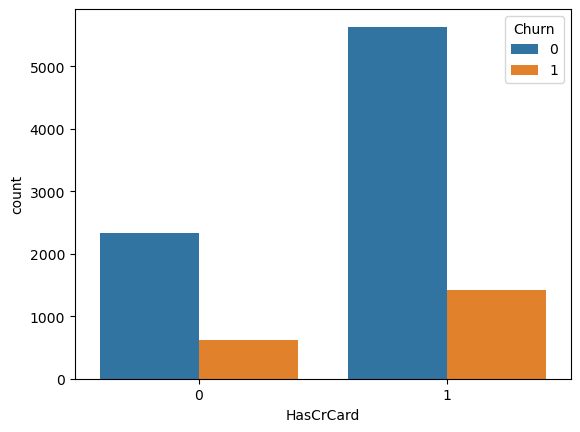

In [ ]:
sns.countplot(data=bank_data, x='HasCrCard', hue='Churn')

The graph shows that majority of customers have credit cards and the ones who doesn't have are very much less than those eho have. However, the number of customers leaving the bank are more of people who have credit card. 

Active Members 

<Axes: xlabel='IsActiveMember', ylabel='count'>

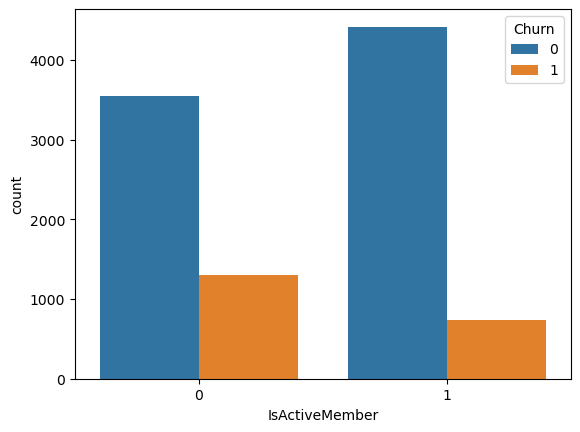

In [ ]:
sns.countplot(data=bank_data, x='IsActiveMember', hue='Churn')

The graph shows that majority of the customers in the bank are those actively using the bank but the churn rate is high among those who aren't actively using the bank. 

Estimated Salary

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

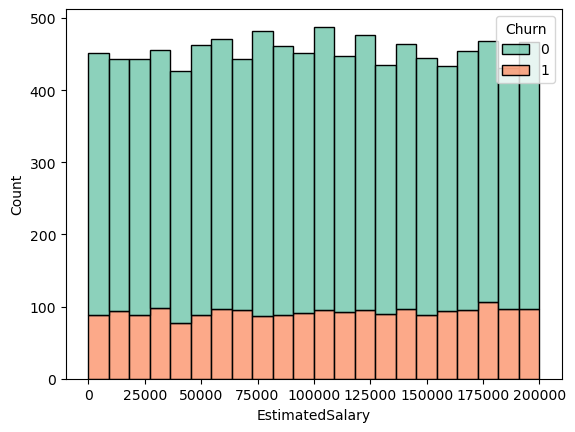

In [144]:
sns.histplot(data=bank_data,x='EstimatedSalary',hue='Churn',multiple='stack',palette='Set2')

Estimated salary is not a good feature to use in our analysis cause there's no special pattern among churners and non-churners. 

Age and Gender

C:\Users\DELL\AppData\Local\Temp\ipykernel_4192\3075061091.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aged = bank_data.groupby(['Gender', pd.cut(bank_data['Age'], bins=[18,35,50,65,92])])['Exited'].mean().reset_index()


   Gender       Age    Exited
0  Female  (18, 35]  0.111050
1  Female  (35, 50]  0.292833
2  Female  (50, 65]  0.613636
3  Female  (65, 92]  0.183333
4    Male  (18, 35]  0.061659
5    Male  (35, 50]  0.205728
6    Male  (50, 65]  0.450292
7    Male  (65, 92]  0.090278


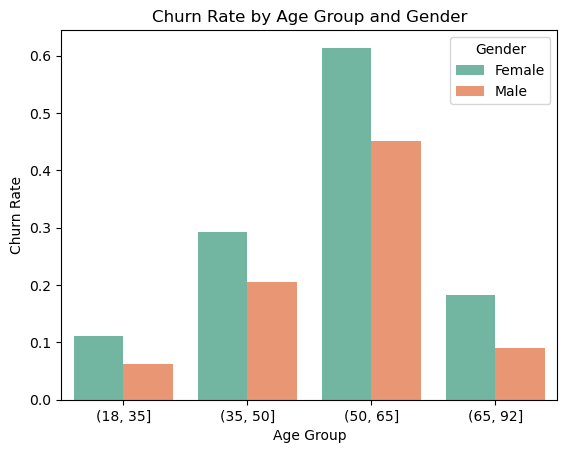

In [ ]:
## Gender and Geography
aged = bank_data.groupby(['Gender', pd.cut(bank_data['Age'], bins=[18,35,50,65,92])])['Exited'].mean().reset_index()
print(aged)
sns.barplot(data=aged, x='Age', y='Exited', hue='Gender', palette='Set2')
plt.title('Churn Rate by Age Group and Gender')
plt.ylabel('Churn Rate')
plt.xlabel('Age Group')
plt.show()

# for females, churn rate is high among people aged (50 - 65) = 61%
# Females churned more than male in all age category. 

This graph explicitily shows that the age range for churners is from 50 - 65 which justifies the previous chart that churners are likely older people than younger ones. 

Gender and Geography

   Gender Geography    Exited
0  Female    France  0.203450
1  Female   Germany  0.375524
2  Female     Spain  0.212121
3    Male    France  0.127134
4    Male   Germany  0.278116
5    Male     Spain  0.131124


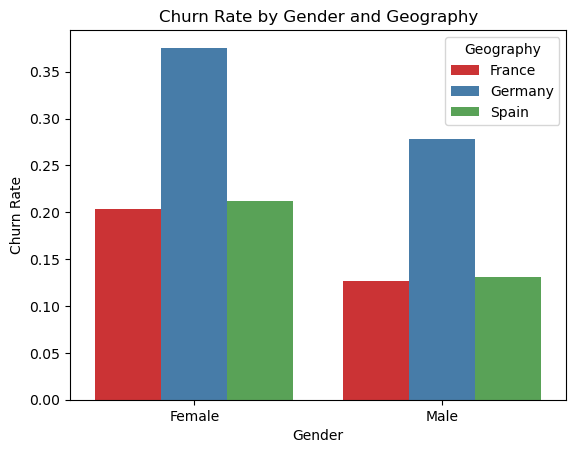

In [ ]:
geo = bank_data.groupby(['Gender', 'Geography'])['Exited'].mean().reset_index()
print(geo)
sns.barplot(data=geo, x='Gender', y='Exited', hue='Geography', palette='Set1')
plt.title('Churn Rate by Gender and Geography')
plt.ylabel('Churn Rate') 
plt.xlabel('Gender')
plt.show()

# churn rate is high in germany for both females and male. 

This graph shows that the churners were mostly females and they are actually located in germany. 

Age and Balance

Age_group  Exited
18-35      0         72433.383481
           1         94115.118000
36-50      0         73170.547343
           1         90948.574206
51-65      0         73712.535864
           1         89807.842879
66-92      0         68245.306376
           1         91451.278571
Name: Balance, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_4192\777810431.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(bank_data.groupby(['Age_group', 'Exited'])['Balance'].mean())


<Axes: xlabel='Age_group', ylabel='Balance'>

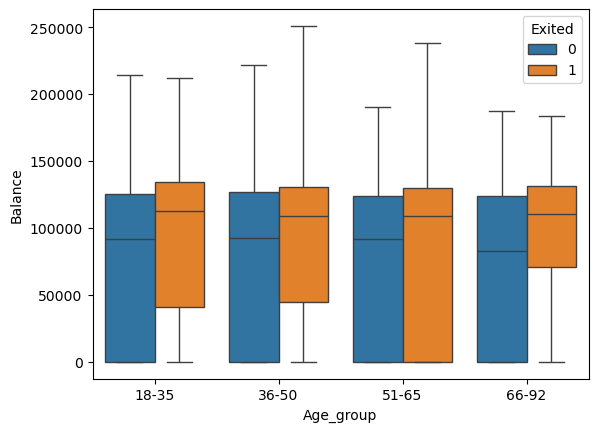

In [ ]:
bank_data['Age_group'] = pd.cut(bank_data['Age'], bins=[18,35,50,65,92], labels=['18-35','36-50','51-65','66-92'])
print(bank_data.groupby(['Age_group', 'Exited'])['Balance'].mean())
sns.boxplot(data=bank_data, x='Age_group', y='Balance', hue='Exited')
## In every of the age bracket, the churners have high percentage than the non-churners. 

This shows that for all age bracket, there was small amount of churners but only in the age bracket 51-65 where we have a high amount of churners and they have low balance. 